In [1]:
#import packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
#import pymannkendall as mk
import cartopy.crs as ccrs
import time
import matplotlib as mpl
#from scipy.stats import linregress
# import dask
import matplotlib.ticker as mticker
import string
letters=[]
for letter in string.ascii_lowercase[0:24]:
    letters.append(letter+". ")
from functionsmlr import *
from sklearn.linear_model import LinearRegression

import scipy.stats as stats

In [2]:
#functions
def cutcanada(dat):

    datout=dat.sel(latitude=slice(40,80), longitude=slice(-142.5,-55))

    return datout

def lineout(dat):
    temp_seas=dat.groupby('time.season')

    # year= np.arange(1950,2025)
    temp_dy_seas=xr.full_like(dat.groupby('time.year').mean().expand_dims(season=titles).copy(),np.nan)

    trseas_mn=[]
    pvseas_mn=[]
    for i,ss in enumerate(titles):
        tempdy=temp_seas[ss].groupby('time.year').mean()
        temp_dy_seas[i,]=tempdy
    #temp_dy_seas_pc=temp_dy_seas.to_dataset(name='tas')
    return temp_dy_seas
def seassum(dat):
    count_days=[90,92,92,91]
    ht_seas=dat.copy()
    for i in range(4):
        ht_seas[i,]=count_days[i]*dat[i,]
    return ht_seas

#prepare mam only
def seas(dat, season):
    dat1=dat.sel(season=season)#-dat.sel(season='SON')
    dat2=dat1.stack(z={'latitude','longitude'})

    lat_radians = np.deg2rad(dat2.unstack().latitude)
    weights = np.cos(lat_radians)

    dat_weighted=dat2.unstack().weighted(weights).mean(("longitude", "latitude"))
    return dat_weighted 

def corsp(dat1,dat2):
    if not np.isnan(dat1).all() and not np.isnan(dat1).all():
        try:
            res = stats.pearsonr(dat1,dat2)
            slope=res[0]
            pval=res[1]
        except:
            slope=np.nan
            pval=np.nan
#         slope_td[i,j]=trend[-2]
#         pval_td[i,j]=trend[2]
    else:
        slope=np.nan
        pval=np.nan
    return slope, pval


def mlr3(X,y):
    try:
        reg = LinearRegression().fit(X, y)
        scores=reg.score(X, y)
        coefficients=reg.coef_
        intercepts=reg.intercept_
    except:
        scores=np.nan
        coefficients=np.array([np.nan,np.nan,np.nan])
        intercepts=np.nan
    return scores, coefficients, intercepts

def mlr2(X,y):
    try:
        reg = LinearRegression().fit(X, y)
        scores=reg.score(X, y)
        coefficients=reg.coef_
        intercepts=reg.intercept_
    except:
        scores=np.nan
        coefficients=np.array([np.nan,np.nan])
        intercepts=np.nan
    return scores, coefficients, intercepts
    
def mlr1(X,y):
    try:
        reg = LinearRegression().fit(X, y)
        scores=reg.score(X, y)
        coefficients=reg.coef_
        intercepts=reg.intercept_
    except:
        scores=np.nan
        coefficients=np.nan
        intercepts=np.nan
    return scores, coefficients, intercepts
def linereg (x,y):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    return slope,intercept



def corsp(dat1,dat2):
    if not np.isnan(dat1).all() and not np.isnan(dat1).all():
        res = stats.pearsonr(dat1,dat2)
        slope=res[0]
        pval=res[1]
#         slope_td[i,j]=trend[-2]
#         pval_td[i,j]=trend[2]
    else:
        slope=np.nan
        pval=np.nan
    return slope, pval

## read Ttr, alb, sm

In [4]:
#historical hot spell changes
change_heathist=xr.open_dataset('HSD_change_midlat_30years_hist_fixed.nc').dHSD

In [6]:
#model names
models1=['ACCESS-CM2','AWI-CM-1-1-MR','BCC-CSM2-MR', 'CanESM5','CESM2','CMCC-ESM2','CNRM-ESM2-1','EC-Earth3-CC','GFDL-ESM4','IITM-ESM','INM-CM5-0','KIOST-ESM','MIROC6','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','NorESM2-MM','TaiESM1']# temp_datcut={}
models22=['CESM2-WACCM', 'CMCC-CM2-SR5', 'CNRM-CM6-1','INM-CM4-8','IPSL-CM6A-LR', 'MIROC-ES2L','CNRM-CM6-1-HR']
models=np.array(models1+models22)

models_alb=np.array(['ACCESS-CM2', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'E3SM-1-1', 'FGOALS-g3', 'IITM-ESM',  'MIROC6', 'MPI-ESM1-2-LR', 'NESM3', 'NorESM2-MM'])
models_albsh=models_alb[np.isin(models_alb,models)]

# models_snow=np.array([ 'BCC-CSM2-MR', 'CanESM5', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'EC-Earth3-CC', 'EC-Earth3-Veg-LR', 'GFDL-ESM4', 'IPSL-CM6A-LR', 'KIOST-ESM', 'MIROC6','MRI-ESM2-0', 'NorESM2-MM', 'TaiESM1'])
# models_snowsh=models_snow[np.isin(models_snow,models)]

models_mrso=np.array(['BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2-WACCM','CESM2','CMCC-CM2-SR5','CMCC-ESM2','CNRM-CM6-1-HR','E3SM-1-1','EC-Earth3-CC','EC-Earth3-Veg-LR', 'MIROC6',  'MIROC-ES2L', 'MPI-ESM1-2-LR','MRI-ESM2-0','NorESM2-LM','NorESM2-MM','TaiESM1'])
models_mrsosh=models_mrso[np.isin(models_mrso,models)]

models_albsm=models_albsh[np.isin(models_albsh,models_mrsosh)]

mnames1=[models_albsh,models_mrsosh]
mnames2=[models_alb,models_mrso]


In [7]:
#read temperature trends
trseas_temphist=xr.open_dataset('cmip6_tas_day_hist2014_mktrends.nc').tas
trseas_temphist=trseas_temphist.assign_coords(models=models)
tmphist_midl=cutmidlat(trseas_temphist)
tmphist_lnd=landmask(tmphist_midl)

trseas_tmp_era=xr.open_dataset('era5_tmean_trend_final_1950-2014.nc').htdays
trseas_tmp_bk=xr.open_dataset('berkeley_tmean_trend_final_1950-2014.nc').htdays

#pvseas_heatfut=xr.open_dataset('../timing/cmip6_heat_fut_mkpvals.nc').tas

In [8]:
#Temp only corrections
x_inp=tmphist_lnd.sel(models=models_albsm)
# x_stack=x_inp.stack(z={'season','latitude','longitude'})
# y_stack=change_heathist.sel(models=models_albsm).stack(z={'season','latitude','longitude'})

y_spat=change_heathist.sel(models=models_albsm).to_dataset(name='t').transpose("season","latitude","longitude","models")[["season", "models","latitude","longitude","t"]].t
x_spat_t=tmphist_lnd.sel(models=models_albsm).to_dataset(name='t').transpose("season","latitude","longitude","models")[["season", "models","latitude","longitude","t"]].t


score_t, pval = xr.apply_ufunc(
        corsp,
        x_spat_t,y_spat,  # your variable (time on first axis)
        input_core_dims=[['models'], ['models']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float]
    )
a, b = xr.apply_ufunc(
        linereg,
        x_spat_t,y_spat,  # your variable (time on first axis)
        input_core_dims=[['models'], ['models']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float]
    )


score_dat_t=score_t#.to_dataset(name='sc')#.transpose("latitude","longitude","season")[["longitude", "latitude","season",'sc']].sc
coef_dat_t=a#.to_dataset(name='sc')#.transpose("latitude","longitude","season")[["longitude", "latitude","season",'sc']].sc
int_dat_t=b#.to_dataset(name='sc')#.transpose("latitude","longitude","season")[["longitude", "latitude","season",'sc']].sc

In [9]:
#tas+albedo
states=['albedo','soilmoisture']
varnames=['__xarray_dataarray_variable__','mrsos']
dsta=[tmphist_lnd.sel(models=models_albsm)]
#for i,d in enumerate(states):
i=0
d=states[i]
trseas_hist=xr.open_dataset('mk_trends2014_'+d+'_cmip.nc')
trseas_hist=(trseas_hist.rename({'model':'models'})[varnames[i]].assign_coords(models=mnames2[i]))#.rename({'model','models'})
hist_midl=cutmidlat(trseas_hist)
hist_lnd=landmask(hist_midl)
albinp=hist_lnd.sel(models=models_albsm)


#pvseas_heatfut=xr.open_dataset('../timing/cmip6_heat_fut_mkpvals.nc').tas

In [10]:
#spatial corr historical changes
#change_heat=htfut_lndclim.sel(year=slice(1984,2014)).mean(dim='year') - htfut_lndclim.sel(year=slice(1950,1980)).mean(dim='year') 

features=['temp','albedo']
x_inp_ta=xr.concat([tmphist_lnd.sel(models=models_albsm),albinp],dim='features').assign_coords(features=features)

x_stack=x_inp_ta.stack(z={'season','latitude','longitude'})
y_stack=change_heathist.sel(models=models_albsm).stack(z={'season','latitude','longitude'})

x_spat=x_stack.to_dataset(name='t').transpose("models","z","features")[["features", "models", "z","t"]].t
y_spat=y_stack.copy()#to_dataset(name='t').transpose("models","z")[["models", "z","features","t"]].t
score_ta, coef_ta, intr_ta = xr.apply_ufunc(
        mlr2,
        x_spat,y_spat,  # your variable (time on first axis)
        input_core_dims=[['models','features'], ['models']],
        output_core_dims=[[], ['features'],[]],
        vectorize=True,
        dask='parallelized',
        
    )

score_dat_ta=score_ta.unstack().to_dataset(name='sc').transpose("latitude","longitude","season")[["longitude", "latitude","season",'sc']].sc
coef_dat_ta=coef_ta.unstack().to_dataset(name='sc').transpose("features","latitude","longitude","season")[["features","longitude", "latitude","season",'sc']].sc
int_dat_ta=intr_ta.unstack().to_dataset(name='sc').transpose("latitude","longitude","season")[["longitude", "latitude","season",'sc']].sc

In [11]:
#tas+soil moisture
states=['albedo','soilmoisture']
varnames=['__xarray_dataarray_variable__','mrsos']
dsta=[tmphist_lnd.sel(models=models_albsm)]
#for i,d in enumerate(states):
i=1
d=states[i]
trseas_hist=xr.open_dataset('mk_trends2014_'+d+'_cmip.nc')
trseas_hist=(trseas_hist.rename({'model':'models'})[varnames[i]].assign_coords(models=mnames2[i]))#.rename({'model','models'})
hist_midl=cutmidlat(trseas_hist)
hist_lnd=landmask(hist_midl)
mrsinp=hist_lnd.sel(models=models_albsm)

In [12]:
#spatial corr historical changes
#change_heat=htfut_lndclim.sel(year=slice(1984,2014)).mean(dim='year') - htfut_lndclim.sel(year=slice(1950,1980)).mean(dim='year') 

features=['temp','soilmoisture']

x_inp_ts=xr.concat([tmphist_lnd.sel(models=models_albsm),mrsinp],dim='features').assign_coords(features=features)

x_stack=x_inp_ts.stack(z={'season','latitude','longitude'})
y_stack=change_heathist.sel(models=models_albsm).stack(z={'season','latitude','longitude'})

x_spat=x_stack.to_dataset(name='t').transpose("models","z","features")[["features", "models", "z","t"]].t
y_spat=y_stack.copy()#to_dataset(name='t').transpose("models","z")[["models", "z","features","t"]].t
score_ts, coef_ts, intr_ts = xr.apply_ufunc(
        mlr2,
        x_spat,y_spat,  # your variable (time on first axis)
        input_core_dims=[['models','features'], ['models']],
        output_core_dims=[[], ['features'],[]],
        vectorize=True,
        dask='parallelized',
        
    )

score_dat_ts=score_ts.unstack().to_dataset(name='sc').transpose("latitude","longitude","season")[["longitude", "latitude","season",'sc']].sc
coef_dat_ts=coef_ts.unstack().to_dataset(name='sc').transpose("features","latitude","longitude","season")[["features","longitude", "latitude","season",'sc']].sc
int_dat_ts=intr_ts.unstack().to_dataset(name='sc').transpose("latitude","longitude","season")[["longitude", "latitude","season",'sc']].sc

In [13]:
#tas+albedo+soil moisture
states=['albedo','soilmoisture']
varnames=['__xarray_dataarray_variable__','mrsos']
dsta=[tmphist_lnd.sel(models=models_albsm)]
for i,d in enumerate(states):

    d=states[i]
    trseas_hist=xr.open_dataset('mk_trends2014_'+d+'_cmip.nc')
    trseas_hist=(trseas_hist.rename({'model':'models'})[varnames[i]].assign_coords(models=mnames2[i]))#.rename({'model','models'})
    hist_midl=cutmidlat(trseas_hist)
    hist_lnd=landmask(hist_midl)
    
    
    dsta.append(hist_lnd.sel(models=models_albsm))


#pvseas_heatfut=xr.open_dataset('../timing/cmip6_heat_fut_mkpvals.nc').tas

In [14]:
#spatial corr historical changes
#change_heat=htfut_lndclim.sel(year=slice(1984,2014)).mean(dim='year') - htfut_lndclim.sel(year=slice(1950,1980)).mean(dim='year') 

features=['temp','albedo','soilmoisture']
x_inp_tas=xr.concat([dsta[0].drop_vars('height'),dsta[1],dsta[2]],dim='features').assign_coords(features=features)

x_stack=x_inp_tas.stack(z={'season','latitude','longitude'})
y_stack=change_heathist.sel(models=models_albsm).stack(z={'season','latitude','longitude'})

x_spat=x_stack.to_dataset(name='t').transpose("models","z","features")[["features", "models", "z","t"]].t
y_spat=y_stack.copy()#to_dataset(name='t').transpose("models","z")[["models", "z","features","t"]].t
score_tas, coef_tas, intr_tas = xr.apply_ufunc(
        mlr3,
        x_spat,y_spat,  # your variable (time on first axis)
        input_core_dims=[['models','features'], ['models']],
        output_core_dims=[[], ['features'],[]],
        vectorize=True,
        dask='parallelized',
        
    )

score_dat_tas=score_tas.unstack().to_dataset(name='sc').transpose("latitude","longitude","season")[["longitude", "latitude","season",'sc']].sc
coef_dat_tas=coef_tas.unstack().to_dataset(name='sc').transpose("features","latitude","longitude","season")[["features","longitude", "latitude","season",'sc']].sc
int_dat_tas=intr_tas.unstack().to_dataset(name='sc').transpose("latitude","longitude","season")[["longitude", "latitude","season",'sc']].sc

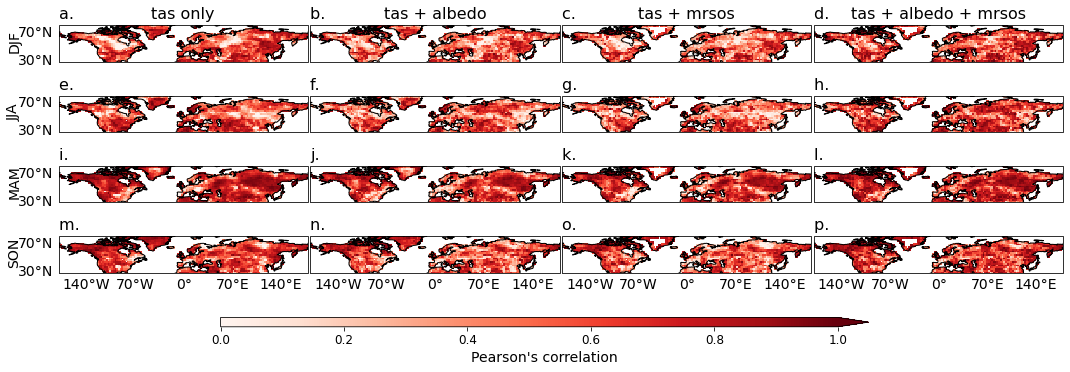

In [43]:
#plot spatial CORR HIST
fig=plt.figure(figsize=(18,6.5))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')
#plt.suptitle("Hotspell trend (MAM - SON) against different parameters (MAM - SON) ",x=0.05, ha='left', fontsize=14,fontweight='bold')

# for i in range(25):
#     ax.scatter(xtmp_all.isel(models=i),10*yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
#ax.vlines(xtmp, ymin=10*ylow, ymax=10*yup, color=cmap(0.8),alpha=1, linestyle='--')


# ax.scatter(xera_all,10*yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')
# ax.scatter(xbk_all,10*ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')
order=[0,2,1,3]

for i,season in enumerate(change_heathist.season.values):
    
    ax=fig.add_subplot(4,4,4*i+1, projection=ccrs.PlateCarree())
    m_v=score_dat_t.isel(season=order[i]).plot(ax=ax, cmap='Reds', vmax=1, vmin=0, add_colorbar=False)
    #ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)

    if i==0:
        ax.set_title("tas only", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i], loc='left', fontsize=16)
    ax.text(-0.15, 0.55, season, va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=14)
 #ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    if i<3:
        gl.bottom_labels = False
    #gl.left_labels = False
        
    ax=fig.add_subplot(4,4,4*i+2, projection=ccrs.PlateCarree())
    m_v=score_dat_ta.isel(season=order[i]).plot(ax=ax, cmap='Reds', vmax=1, vmin=0, add_colorbar=False)
    #ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)
    
    
    if i==0:
        ax.set_title("tas + albedo", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i+1], loc='left', fontsize=16)
#ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    if i<3:
        gl.bottom_labels = False
    gl.left_labels = False
    
    ax=fig.add_subplot(4,4,4*i+3, projection=ccrs.PlateCarree())
    m_v=score_dat_ts.isel(season=order[i]).plot(ax=ax, cmap='Reds', vmax=1, vmin=0, add_colorbar=False)
    #ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)

    
    if i==0:
        ax.set_title("tas + mrsos", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i+2], loc='left', fontsize=16)
#ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()

    gl.left_labels = False
    if i<3:
        gl.bottom_labels = False
    
    ax=fig.add_subplot(4,4,4*i+4, projection=ccrs.PlateCarree())
    m_v=score_dat_tas.isel(season=order[i]).plot(ax=ax, cmap='Reds', vmax=1, vmin=0, add_colorbar=False)
    #ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)
    
    
    if i==0:
        ax.set_title("tas + albedo + mrsos", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i+3], loc='left', fontsize=16)
#ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    if i<3:
        gl.bottom_labels = False
    gl.left_labels = False
    
    


cbar_ax = fig.add_axes([0.25, 0.2, 0.5, 0.02])
cbl=fig.colorbar(m_v, cax=cbar_ax, extend='max',orientation='horizontal')
cbl.set_label(label="Pearson's correlation",size=14)
cbl.ax.tick_params(labelsize=12) 
plt.subplots_adjust(hspace=0.01, wspace=0.01, bottom=0.28)
#plt.tight_layout()
plt.savefig('Plots/mlr_compare_scores.png')


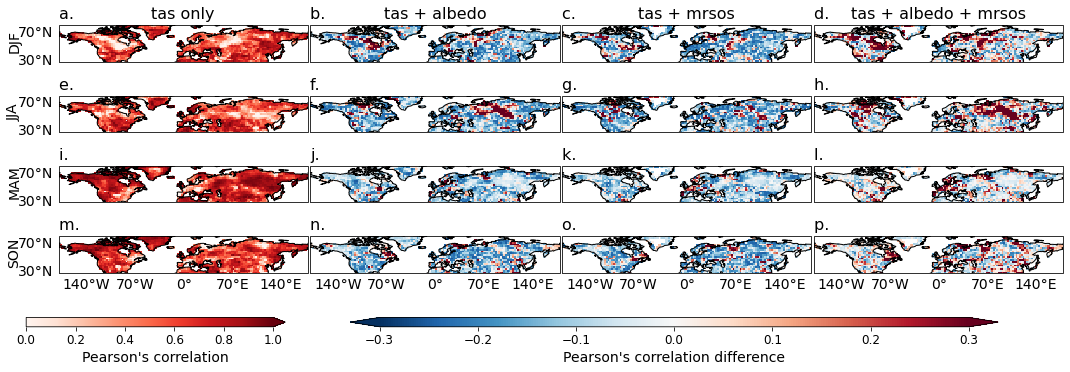

In [42]:
#plot spatial CORR HIST
fig=plt.figure(figsize=(18,6.5))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')
#plt.suptitle("Hotspell trend (MAM - SON) against different parameters (MAM - SON) ",x=0.05, ha='left', fontsize=14,fontweight='bold')

# for i in range(25):
#     ax.scatter(xtmp_all.isel(models=i),10*yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
#ax.vlines(xtmp, ymin=10*ylow, ymax=10*yup, color=cmap(0.8),alpha=1, linestyle='--')


# ax.scatter(xera_all,10*yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')
# ax.scatter(xbk_all,10*ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')
order=[0,2,1,3]

for i,season in enumerate(change_heathist.season.values):
    
    ax=fig.add_subplot(4,4,4*i+1, projection=ccrs.PlateCarree())
    m_v=score_dat_t.isel(season=order[i]).plot(ax=ax, cmap='Reds', vmax=1, vmin=0, add_colorbar=False)
    #ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)

    if i==0:
        ax.set_title("tas only", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i], loc='left', fontsize=16)
    ax.text(-0.15, 0.55, season, va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=14)
 #ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    #gl.left_labels = False
    if i<3:
        gl.bottom_labels = False
    ax=fig.add_subplot(4,4,4*i+2, projection=ccrs.PlateCarree())
    m_2=(score_dat_ta- score_dat_t).isel(season=order[i]).plot(ax=ax, cmap='RdBu_r', vmax=0.3, vmin=-0.3, add_colorbar=False)
    #ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)
    
    
    if i==0:
        ax.set_title("tas + albedo", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i+1], loc='left', fontsize=16)
#ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    if i<3:
        gl.bottom_labels = False
    gl.left_labels = False
    
    ax=fig.add_subplot(4,4,4*i+3, projection=ccrs.PlateCarree())
    m_2=(score_dat_ts- score_dat_t).isel(season=order[i]).plot(ax=ax, cmap='RdBu_r', vmax=0.3, vmin=-0.3, add_colorbar=False)
    #ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)

    
    if i==0:
        ax.set_title("tas + mrsos", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i+2], loc='left', fontsize=16)
#ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()

    gl.left_labels = False
    if i<3:
        gl.bottom_labels = False
    
    ax=fig.add_subplot(4,4,4*i+4, projection=ccrs.PlateCarree())
    m_2=(score_dat_tas- score_dat_t).isel(season=order[i]).plot(ax=ax, cmap='RdBu_r', vmax=0.3, vmin=-0.3, add_colorbar=False)
    #ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)
    
    
    if i==0:
        ax.set_title("tas + albedo + mrsos", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i+3], loc='left', fontsize=16)
#ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    if i<3:
        gl.bottom_labels = False
    gl.left_labels = False
    
    


cbar_ax = fig.add_axes([0.1, 0.2, 0.2, 0.02])
cbl=fig.colorbar(m_v, cax=cbar_ax, extend='max',orientation='horizontal')
cbl.set_label(label="Pearson's correlation",size=14)
cbl.ax.tick_params(labelsize=12) 
plt.subplots_adjust(hspace=0.01, wspace=0.01, bottom=0.28)

cbar_ax = fig.add_axes([0.35, 0.2, 0.5, 0.02])
cbl=fig.colorbar(m_2, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="Pearson's correlation difference",size=14)
cbl.ax.tick_params(labelsize=12) 
plt.subplots_adjust(hspace=0.01, wspace=0.01, bottom=0.28)
#plt.tight_layout()
plt.savefig('Plots/mlr_compare_scores_alt.png')


In [15]:
#correct tas only
ht_erabased_t=a*(trseas_tmp_era - x_spat_t.mean(dim='models')) +change_heathist.mean(dim='models')

In [16]:
#correct albedo 
trseas_albedo_era=xr.open_dataset('mk_trends_albedo_era.nc').__xarray_dataarray_variable__

trseas_tmp_era=xr.open_dataset('era5_tmean_trend_final_1950-2014.nc').htdays
#trseas_era=xr.concat([trseas_tmp_era,trseas_mrsos_era],dim='features').assign_coords(features=features)
ht_erabased_ta=coef_dat_ta.sel(features='temp')*(trseas_tmp_era - x_inp_ta.sel(features='temp').mean(dim='models')) +coef_dat_ta.sel(features='albedo')*(trseas_albedo_era - x_inp_ta.sel(features='albedo').mean(dim='models')) + change_heathist.mean(dim='models')

In [17]:
#correct soil moisture
trseas_mrsos_era=xr.open_dataset('mk_trends_soilmoisture_era.nc').swvl1

#trseas_tmp_era=xr.open_dataset('era5_tmean_trend_final_1950-2014.nc').htdays
#trseas_era=xr.concat([trseas_tmp_era,trseas_mrsos_era],dim='features').assign_coords(features=features)
ht_erabased_ts=coef_dat_ts.sel(features='temp')*(trseas_tmp_era - x_inp_ts.sel(features='temp').mean(dim='models')) +coef_dat_ts.sel(features='soilmoisture')*(trseas_mrsos_era - x_inp_ts.sel(features='soilmoisture').mean(dim='models')) + change_heathist.mean(dim='models')

In [18]:
#correct sm+alb
ht_erabased_tas=coef_dat_tas.sel(features='temp')*(trseas_tmp_era - x_inp_tas.sel(features='temp').mean(dim='models')) +coef_dat_tas.sel(features='albedo')*(trseas_albedo_era - x_inp_tas.sel(features='albedo').mean(dim='models')) + coef_dat_tas.sel(features='soilmoisture')*(trseas_mrsos_era - x_inp_tas.sel(features='soilmoisture').mean(dim='models')) + change_heathist.mean(dim='models')

In [19]:
#era heat
era_heat=xr.open_dataset('../timing/era5/era5_tmean_heatdays_1950_2024_regrid.nc')
eraht_midl2=cutmidlat(era_heat)
eraht_lnd2=landmask(eraht_midl2)

eraht_lndclim=eraht_lnd2.t2m.groupby("time.year").map(
        lambda x: x.groupby("time.season").sum("time")
    )

change_heat_era=eraht_lndclim.sel(year=slice(1984,2014)).mean(dim='year') - eraht_lndclim.sel(year=slice(1950,1980)).mean(dim='year') 



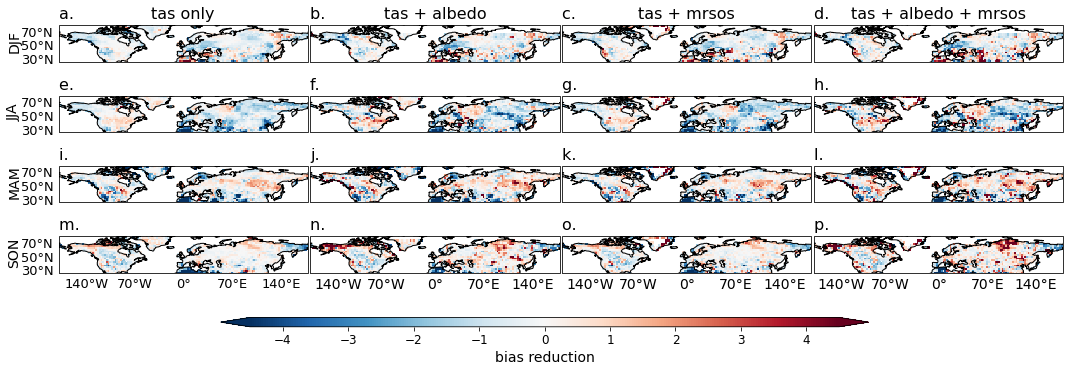

In [64]:
#plot spatial CORR HIST
fig=plt.figure(figsize=(18,6.5))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')
#plt.suptitle("Hotspell trend (MAM - SON) against different parameters (MAM - SON) ",x=0.05, ha='left', fontsize=14,fontweight='bold')

# for i in range(25):
#     ax.scatter(xtmp_all.isel(models=i),10*yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
#ax.vlines(xtmp, ymin=10*ylow, ymax=10*yup, color=cmap(0.8),alpha=1, linestyle='--')


# ax.scatter(xera_all,10*yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')
# ax.scatter(xbk_all,10*ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')
order=[0,2,1,3]

for i,season in enumerate(change_heathist.season.values):
    
    ax=fig.add_subplot(4,4,4*i+1, projection=ccrs.PlateCarree())
    
    dif1=change_heathist.isel(season=order[i]).mean(dim='models') - change_heat_era.isel(season=order[i])
    dif2=ht_erabased_t.isel(season=order[i]) - change_heat_era.isel(season=order[i])
    dif3=abs(dif2) - abs(dif1)

    m2=(dif3).plot(ax=ax, cmap='RdBu_r', vmin=-4.5,vmax=4.5,transform=ccrs.PlateCarree(),add_colorbar=False)
    #ax.contourf(era_hatch_tr_con.longitude,era_hatch_tr_con.latitude, era_hatch_tr_con.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False

    #gl.left_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    
    if i<3:
        gl.bottom_labels = False
        
        
    ax.set_title(letters[3*i+2],loc='left',fontsize=16, y=0.96)
    #ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)
    
    if i==0:
        ax.set_title("tas only", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i], loc='left', fontsize=16)
    ax.text(-0.15, 0.55, season, va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=14)
 #ax.set_xticks(np.arange(0,0.9,0.3))
    
    ax=fig.add_subplot(4,4,4*i+2, projection=ccrs.PlateCarree())
    #dif1=change_heathist.isel(season=order[i]).mean(dim='models') - change_heat_era.isel(season=order[i])
    dif2=ht_erabased_ta.isel(season=order[i]) - change_heat_era.isel(season=order[i])
    dif3=abs(dif2) - abs(dif1)

    m2=(dif3).plot(ax=ax, cmap='RdBu_r', vmin=-4.5,vmax=4.5,transform=ccrs.PlateCarree(),add_colorbar=False)
    #ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)
    
    
    if i==0:
        ax.set_title("tas + albedo", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i+1], loc='left', fontsize=16)
#ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    if i<3:
        gl.bottom_labels = False
    gl.left_labels = False
    
    ax=fig.add_subplot(4,4,4*i+3, projection=ccrs.PlateCarree())
    #dif1=change_heathist.isel(season=order[i]).mean(dim='models') - change_heat_era.isel(season=order[i])
    dif2=ht_erabased_ts.isel(season=order[i]) - change_heat_era.isel(season=order[i])
    dif3=abs(dif2) - abs(dif1)

    m2=(dif3).plot(ax=ax, cmap='RdBu_r', vmin=-4.5,vmax=4.5,transform=ccrs.PlateCarree(),add_colorbar=False)#ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)

    
    if i==0:
        ax.set_title("tas + mrsos", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i+2], loc='left', fontsize=16)
#ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()

    gl.left_labels = False
    if i<3:
        gl.bottom_labels = False
    
    ax=fig.add_subplot(4,4,4*i+4, projection=ccrs.PlateCarree())
    dif2=ht_erabased_tas.isel(season=order[i]) - change_heat_era.isel(season=order[i])
    dif3=abs(dif2) - abs(dif1)

    m2=(dif3).plot(ax=ax, cmap='RdBu_r', vmin=-4.5,vmax=4.5,transform=ccrs.PlateCarree(),add_colorbar=False)#ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)
#ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)
    
    
    if i==0:
        ax.set_title("tas + albedo + mrsos", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i+3], loc='left', fontsize=16)
#ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    if i<3:
        gl.bottom_labels = False
    gl.left_labels = False
    
    


cbar_ax = fig.add_axes([0.25, 0.2, 0.5, 0.02])
cbl=fig.colorbar(m1, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="bias reduction",size=14)
cbl.ax.tick_params(labelsize=12) 
plt.subplots_adjust(hspace=0.01, wspace=0.01, bottom=0.28)
#plt.tight_layout()
plt.savefig('Plots/corrected_8models.png')


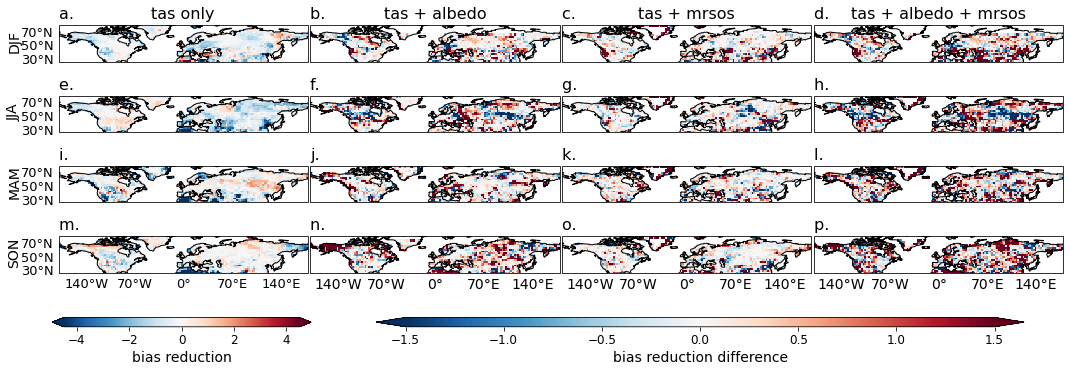

In [21]:
#plot spatial CORR HIST
fig=plt.figure(figsize=(18,6.5))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')
#plt.suptitle("Hotspell trend (MAM - SON) against different parameters (MAM - SON) ",x=0.05, ha='left', fontsize=14,fontweight='bold')

# for i in range(25):
#     ax.scatter(xtmp_all.isel(models=i),10*yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
#ax.vlines(xtmp, ymin=10*ylow, ymax=10*yup, color=cmap(0.8),alpha=1, linestyle='--')


# ax.scatter(xera_all,10*yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')
# ax.scatter(xbk_all,10*ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')
order=[0,2,1,3]

for i,season in enumerate(change_heathist.season.values):
    
    ax=fig.add_subplot(4,4,4*i+1, projection=ccrs.PlateCarree())
    
    dif1=change_heathist.isel(season=order[i]).mean(dim='models') - change_heat_era.isel(season=order[i])
    dif2=ht_erabased_t.isel(season=order[i]) - change_heat_era.isel(season=order[i])
    dif3_t=abs(dif2) - abs(dif1)

    m1=(dif3_t).plot(ax=ax, cmap='RdBu_r', vmin=-4.5,vmax=4.5,transform=ccrs.PlateCarree(),add_colorbar=False)
    #ax.contourf(era_hatch_tr_con.longitude,era_hatch_tr_con.latitude, era_hatch_tr_con.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False

    #gl.left_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    
    if i<3:
        gl.bottom_labels = False
        
        
    ax.set_title(letters[3*i+2],loc='left',fontsize=16, y=0.96)
    #ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)
    
    if i==0:
        ax.set_title("tas only", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i], loc='left', fontsize=16)
    ax.text(-0.15, 0.55, season, va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=14)
 #ax.set_xticks(np.arange(0,0.9,0.3))
    
    ax=fig.add_subplot(4,4,4*i+2, projection=ccrs.PlateCarree())
    #dif1=change_heathist.isel(season=order[i]).mean(dim='models') - change_heat_era.isel(season=order[i])
    dif2=ht_erabased_ta.isel(season=order[i]) - change_heat_era.isel(season=order[i])
    dif3=abs(dif2) - abs(dif1)

    m2=(dif3 - dif3_t).plot(ax=ax, cmap='RdBu_r', vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree(),add_colorbar=False)
    #ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)
    
    
    if i==0:
        ax.set_title("tas + albedo", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i+1], loc='left', fontsize=16)
#ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    if i<3:
        gl.bottom_labels = False
    gl.left_labels = False
    
    ax=fig.add_subplot(4,4,4*i+3, projection=ccrs.PlateCarree())
    #dif1=change_heathist.isel(season=order[i]).mean(dim='models') - change_heat_era.isel(season=order[i])
    dif2=ht_erabased_ts.isel(season=order[i]) - change_heat_era.isel(season=order[i])
    dif3=abs(dif2) - abs(dif1)

    m2=(dif3-dif3_t).plot(ax=ax, cmap='RdBu_r',  vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree(),add_colorbar=False)#ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)

    
    if i==0:
        ax.set_title("tas + mrsos", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i+2], loc='left', fontsize=16)
#ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()

    gl.left_labels = False
    if i<3:
        gl.bottom_labels = False
    
    ax=fig.add_subplot(4,4,4*i+4, projection=ccrs.PlateCarree())
    dif2=ht_erabased_tas.isel(season=order[i]) - change_heat_era.isel(season=order[i])
    dif3=abs(dif2) - abs(dif1)

    m2=(dif3 - dif3_t).plot(ax=ax, cmap='RdBu_r',  vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree(),add_colorbar=False)#ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)
#ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)
    
    
    if i==0:
        ax.set_title("tas + albedo + mrsos", fontsize=16)
    else:
        ax.set_title(" ")
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[4*i+3], loc='left', fontsize=16)
#ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    if i<3:
        gl.bottom_labels = False
    gl.left_labels = False
    
    


cbar_ax = fig.add_axes([0.12, 0.2, 0.2, 0.02])
cbl=fig.colorbar(m1, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="bias reduction",size=14)
cbl.ax.tick_params(labelsize=12) 
plt.subplots_adjust(hspace=0.01, wspace=0.01, bottom=0.28)

cbar_ax = fig.add_axes([0.37, 0.2, 0.5, 0.02])
cbl=fig.colorbar(m2, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="bias reduction difference",size=14)
cbl.ax.tick_params(labelsize=12) 
plt.subplots_adjust(hspace=0.01, wspace=0.01, bottom=0.28)
#plt.tight_layout()
plt.savefig('Plots/corrected_8models_alt.png')
